In [ ]:
from __future__ import print_function
from __future__ import division
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
print("PyTorch Version: ",torch.__version__)
print("Torchvision Version: ",torchvision.__version__)

PyTorch Version:  2.9.0+cu126
Torchvision Version:  0.24.0+cu126


In [ ]:
 #Link Google Drive with Colab to Access Data

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rsync -av /content/drive/MyDrive/Insects/Data /content/data_local


Streaming output truncated to the last 5000 lines.
Data/train/culex/culex_1625.jpeg
Data/train/culex/culex_1626.jpeg
Data/train/culex/culex_1629.jpeg
Data/train/culex/culex_163.jpeg
Data/train/culex/culex_1631.jpeg
Data/train/culex/culex_1632.jpeg
Data/train/culex/culex_1635.jpeg
Data/train/culex/culex_1636.jpeg
Data/train/culex/culex_1638.jpeg
Data/train/culex/culex_164.jpeg
Data/train/culex/culex_1641.jpeg
Data/train/culex/culex_1644.jpeg
Data/train/culex/culex_1645.jpeg
Data/train/culex/culex_1647.jpeg
Data/train/culex/culex_1648.jpeg
Data/train/culex/culex_1650.jpeg
Data/train/culex/culex_1651.jpeg
Data/train/culex/culex_1652.jpeg
Data/train/culex/culex_1653.jpeg
Data/train/culex/culex_1654.jpeg
Data/train/culex/culex_1655.jpeg
Data/train/culex/culex_1658.jpeg
Data/train/culex/culex_166.jpeg
Data/train/culex/culex_1660.jpeg
Data/train/culex/culex_1661.jpeg
Data/train/culex/culex_1662.jpeg
Data/train/culex/culex_1664.jpeg
Data/train/culex/culex_1665.jpeg
Data/train/culex/culex_1667.

In [ ]:
!ls /content/data_local


Data


In [ ]:
!ls /content/data_local/Data


test  train  val


In [ ]:
# define training and test data directories

data_dir = 'path/to/dataset'
train_dir = os.path.join(data_dir, 'train/')
valid_dir = os.path.join(data_dir, 'val/')
#test_dir = os.path.join(data_dir, 'test/')

# classes are folders in each directory with these names
classes = ['aedes', 'anopheles', 'cimex', 'ctenocephalides', 'culex', 'pediculus', 'triatoma' ]

In [ ]:
model_name = "convnext_large"

# Number of classes in the dataset
num_classes = 7

# Batch size for training
batch_size = 32

# Number of epochs to train for
num_epochs = 30

# Flag for feature extracting. When False, we finetune the whole model,
#   when True we only update the reshaped layer params
feature_extract = False

In [ ]:
from torch.amp import autocast, GradScaler

# Initialize the AMP GradScaler
scaler = GradScaler()

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=30, is_inception=False):
    since = time.time()

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                if phase == 'train':

                    with autocast("cuda"):
                        if is_inception:
                            outputs, aux_outputs = model(inputs)
                            loss1 = criterion(outputs, labels)
                            loss2 = criterion(aux_outputs, labels)
                            loss = loss1 + 0.4 * loss2
                        else:
                            outputs = model(inputs)
                            loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()

                else:

                    with torch.no_grad():
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        _, preds = torch.max(outputs, 1)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # Save history
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.cpu().item())
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.cpu().item())
                lr_scheduler.step(epoch_acc)

                # Save best model
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    model.load_state_dict(best_model_wts)
    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history

In [ ]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [ ]:
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    # Initialize these variables which will be set in this if statement. Each of these
    #   variables is model specific.
    model_ft = None
    input_size = 0

    if model_name == "convnext_large":
        from torchvision.models import convnext_large, ConvNeXt_Large_Weights

        weights = ConvNeXt_Large_Weights.DEFAULT if use_pretrained else None
        model_ft = convnext_large(weights=weights)

        set_parameter_requires_grad(model_ft, feature_extract)

        in_features = model_ft.classifier[2].in_features
        model_ft.classifier[2] = nn.Linear(in_features, num_classes)

        input_size = 224

    return model_ft, input_size



In [ ]:
# Initialize the model for this run
model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

# Print the model we just instantiated
print(model_ft)

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((192,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(192, 192, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=192)
          (1): Permute()
          (2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=192, out_features=768, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=768, out_features=192, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(192, 192, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=192)
          (1): Permute()
          (2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
          (3): Linear(

In [ ]:
print("Model name is:", model_name)

Model name is: convnext_large


In [ ]:
#class weights for imbalance
class_counts = torch.tensor([2250, 2250, 1187, 2250, 2250, 532, 2250], dtype=torch.float)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

In [ ]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(20),
        transforms.RandomPerspective(distortion_scale=0.4, p=0.4),
        transforms.ColorJitter(0.3, 0.3, 0.3, 0.02),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.15, scale=(0.02, 0.1),ratio=(0.3, 3.3)),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])


    ]),

    'val': transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


print("Initializing Datasets and Dataloaders...")


Initializing Datasets and Dataloaders...


In [ ]:
# Create training and validation datasets
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val']
}


from torch.utils.data import WeightedRandomSampler

targets = [label for _, label in image_datasets['train']]
sample_weights = [class_weights[label].item() for label in targets]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = torch.utils.data.DataLoader(
    image_datasets['train'],
    batch_size=batch_size,
    sampler=sampler,
    num_workers=4
)

val_loader = torch.utils.data.DataLoader(
    image_datasets['val'],
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

test_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "test"),
    data_transforms["val"]
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

dataloaders_dict = {
    "train": train_loader,
    "val": val_loader
}

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# Send the model to GPU
model_ft = model_ft.to(device)

# Gather the parameters to be optimized/updated in this run. If we are
#  finetuning we will be updating all parameters. However, if we are
#  doing feature extract method, we will only update the parameters
#  that we have just initialized, i.e. the parameters with requires_grad
#  is True.
params_to_update = model_ft.parameters()
print("Params to learn:")
if feature_extract:
    params_to_update = []
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            params_to_update.append(param)
            print("\t",name)
else:
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            print("\t",name)

# Observe that all parameters are being optimized
optimizer_ft = optim.AdamW(params_to_update, lr=2e-5, weight_decay=1e-4)

lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode='max',
    factor=0.3,
    patience=3
)

Params to learn:
	 features.0.0.weight
	 features.0.0.bias
	 features.0.1.weight
	 features.0.1.bias
	 features.1.0.layer_scale
	 features.1.0.block.0.weight
	 features.1.0.block.0.bias
	 features.1.0.block.2.weight
	 features.1.0.block.2.bias
	 features.1.0.block.3.weight
	 features.1.0.block.3.bias
	 features.1.0.block.5.weight
	 features.1.0.block.5.bias
	 features.1.1.layer_scale
	 features.1.1.block.0.weight
	 features.1.1.block.0.bias
	 features.1.1.block.2.weight
	 features.1.1.block.2.bias
	 features.1.1.block.3.weight
	 features.1.1.block.3.bias
	 features.1.1.block.5.weight
	 features.1.1.block.5.bias
	 features.1.2.layer_scale
	 features.1.2.block.0.weight
	 features.1.2.block.0.bias
	 features.1.2.block.2.weight
	 features.1.2.block.2.bias
	 features.1.2.block.3.weight
	 features.1.2.block.3.bias
	 features.1.2.block.5.weight
	 features.1.2.block.5.bias
	 features.2.0.weight
	 features.2.0.bias
	 features.2.1.weight
	 features.2.1.bias
	 features.3.0.layer_scale
	 features.

In [ ]:
# Setup the loss fxn
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Train and evaluate
# Train and evaluate
model_ft, train_loss, val_loss, train_acc, val_acc = train_model(
    model_ft,
    dataloaders_dict,
    criterion,
    optimizer_ft,
    num_epochs=num_epochs,
    is_inception=False
)


Epoch 0/29
----------
train Loss: 0.6850 Acc: 0.7075
val Loss: 0.3021 Acc: 0.9202

Epoch 1/29
----------
train Loss: 0.1591 Acc: 0.9387
val Loss: 0.1445 Acc: 0.9475

Epoch 2/29
----------
train Loss: 0.0888 Acc: 0.9640
val Loss: 0.1058 Acc: 0.9629

Epoch 3/29
----------
train Loss: 0.0683 Acc: 0.9678
val Loss: 0.0808 Acc: 0.9706

Epoch 4/29
----------
train Loss: 0.0518 Acc: 0.9757
val Loss: 0.0687 Acc: 0.9753

Epoch 5/29
----------
train Loss: 0.0432 Acc: 0.9786
val Loss: 0.0664 Acc: 0.9773

Epoch 6/29
----------
train Loss: 0.0377 Acc: 0.9816
val Loss: 0.0574 Acc: 0.9809

Epoch 7/29
----------
train Loss: 0.0319 Acc: 0.9845
val Loss: 0.0569 Acc: 0.9784

Epoch 8/29
----------
train Loss: 0.0310 Acc: 0.9845
val Loss: 0.0506 Acc: 0.9825

Epoch 9/29
----------
train Loss: 0.0236 Acc: 0.9889
val Loss: 0.0565 Acc: 0.9820

Epoch 10/29
----------
train Loss: 0.0259 Acc: 0.9876
val Loss: 0.0641 Acc: 0.9794

Epoch 11/29
----------
train Loss: 0.0192 Acc: 0.9909
val Loss: 0.0534 Acc: 0.9830

Ep

In [ ]:
print("train_loss =", train_loss)
print("val_loss =", val_loss)
print("train_acc =", train_acc)
print("val_acc =", val_acc)

train_loss = [0.6850364421592754, 0.1590999101480495, 0.08884549717733456, 0.0682840356988456, 0.051815873919745445, 0.043170378962741694, 0.0377032257359999, 0.03192956436006655, 0.030983845820685956, 0.023617825374477344, 0.02587540205980158, 0.01924333642727085, 0.017380165938450244, 0.016712001684730204, 0.01444559253260319, 0.013183454887432536, 0.012495383928466301, 0.011650412657175393, 0.012428590290121312, 0.011092966168171474, 0.009642351515799721, 0.010586278754362636, 0.009660857605451097, 0.007882353393930435, 0.007339432038253696, 0.0066996078275817494, 0.009636434434305095, 0.008679448112979635, 0.005194199668856555, 0.00427580141314251]
val_loss = [0.30211801286767614, 0.1444963795870512, 0.10579538657632105, 0.08082658126489878, 0.06874393601925807, 0.06639384142728379, 0.057413441188495326, 0.05693419108859788, 0.0506090532473253, 0.05648888714887762, 0.06408395952771463, 0.05336361485279245, 0.05767700489827199, 0.05384854254879663, 0.04990568782210573, 0.05053113470

In [ ]:
def plot_training_curves(train_loss, val_loss, train_acc, val_acc):
    # Convert tensors to floats if needed
    train_loss = [t.cpu().item() if torch.is_tensor(t) else t for t in train_loss]
    val_loss   = [t.cpu().item() if torch.is_tensor(t) else t for t in val_loss]
    train_acc  = [t.cpu().item() if torch.is_tensor(t) else t for t in train_acc]
    val_acc    = [t.cpu().item() if torch.is_tensor(t) else t for t in val_acc]

    epochs = range(len(train_loss))

    plt.figure(figsize=(14,6))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

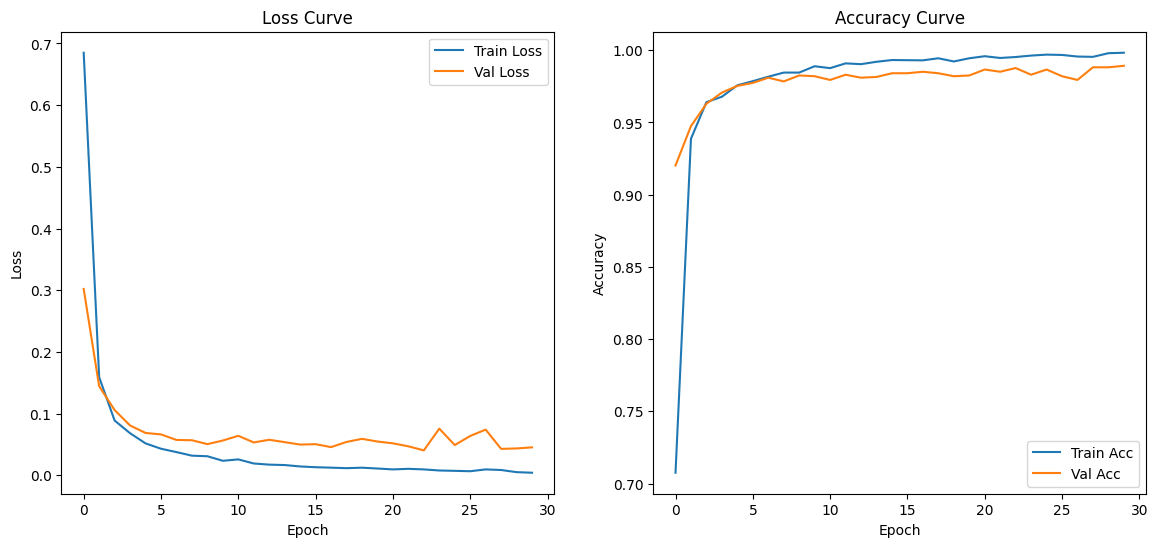

In [ ]:
plot_training_curves(train_loss, val_loss, train_acc, val_acc)

In [ ]:
test_dir = os.path.join(data_dir, "test")

test_dataset = datasets.ImageFolder(
    test_dir,
    data_transforms['val']     # Use validation transforms
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def evaluate_on_test(model, test_loader):
    model.eval()
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    preds_list = np.array(preds_list)
    labels_list = np.array(labels_list)
    return preds_list, labels_list

In [ ]:
y_pred, y_true = evaluate_on_test(model_ft, test_loader)

In [ ]:
test_accuracy = np.mean(y_pred == y_true)
print("Test Accuracy: {:.4f}".format(test_accuracy))

Test Accuracy: 0.9862


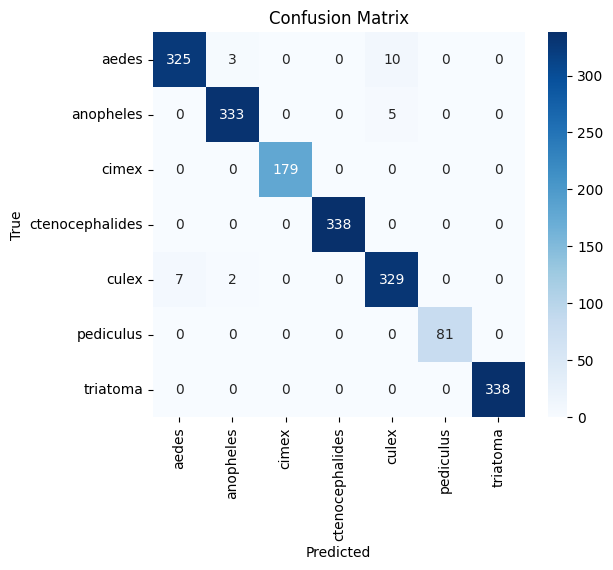

                 precision    recall  f1-score   support

          aedes       0.98      0.96      0.97       338
      anopheles       0.99      0.99      0.99       338
          cimex       1.00      1.00      1.00       179
ctenocephalides       1.00      1.00      1.00       338
          culex       0.96      0.97      0.96       338
      pediculus       1.00      1.00      1.00        81
       triatoma       1.00      1.00      1.00       338

       accuracy                           0.99      1950
      macro avg       0.99      0.99      0.99      1950
   weighted avg       0.99      0.99      0.99      1950



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Per-Class Precision, Recall, F1
print(classification_report(y_true, y_pred, target_names=classes))

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve

model_ft.eval()
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_ft(inputs)
        softmax_scores = torch.softmax(outputs, dim=1)
        all_probs.append(softmax_scores.cpu().numpy())

all_probs = np.vstack(all_probs)  # shape [N,7]
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3, 4, 5, 6])

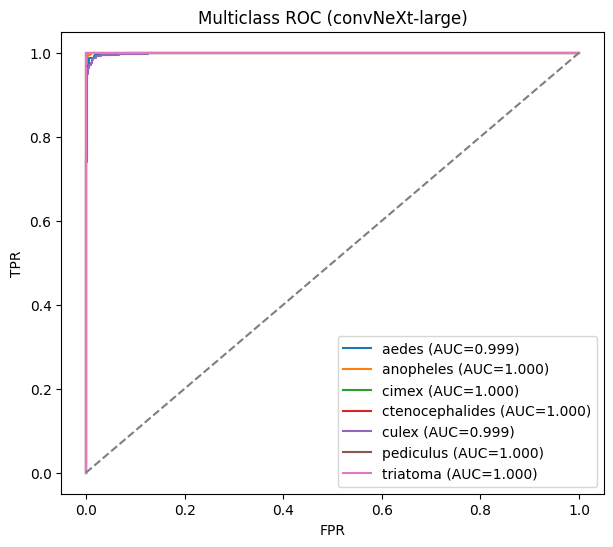

In [ ]:
plt.figure(figsize=(7,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC (convNeXt-large)")
plt.legend()
plt.show()

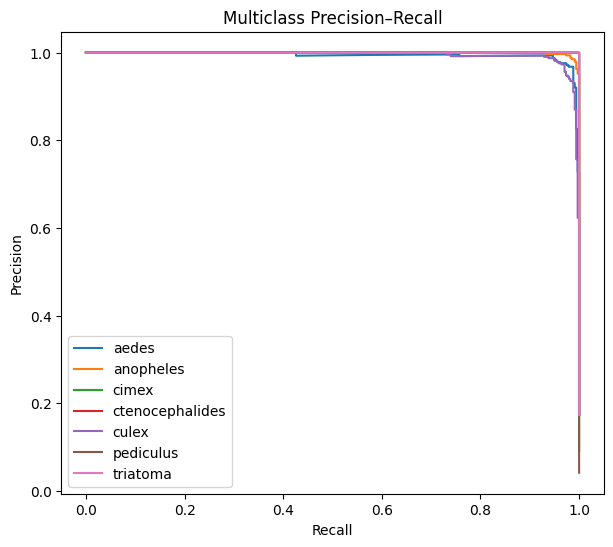

In [ ]:
plt.figure(figsize=(7,6))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], all_probs[:, i])
    plt.plot(recall, precision, label=cls)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass Precision–Recall")
plt.legend()
plt.show()



In [ ]:
torch.save(
    model_ft.state_dict(),
    "/content/drive/MyDrive/Insects/Models/best_ConvNeXt.pth"
)

In [ ]:
model_ft.load_state_dict(torch.load("/content/drive/MyDrive/Insects/Models/best_ConvNeXt.pth"))
model_ft.eval()

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((192,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(192, 192, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=192)
          (1): Permute()
          (2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=192, out_features=768, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=768, out_features=192, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(192, 192, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=192)
          (1): Permute()
          (2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
          (3): Linear(